In [1]:
import matplotlib.pyplot as plt

# Import custom modules
# Add parent directory to path for myPkg imports
import sys
from pathlib import Path

# For notebooks, use current working directory to find parent
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))
    
from myPkg.optimization_utils import OptimizationMonitor
from myPkg.plotting_helpers import plot_fidelity_vs_parameter, plot_optimization_convergence, plot_parameter_vs_parameter, plt_config
from myPkg.utils import *

---
### Optimized Parameters Case 1 : $T = 0.27$ μs $\&$ $\tau/T = 0.175$

In this analysis, we investigate how the optimized pulse amplitudes $\Omega_r$ and $\Delta_r$ vary with the Rydberg blockade strength $B$ under fixed temporal parameters:

- Gate time: $T = 0.27$ μs (fixed)
- Pulse shape parameter: $\tau/T = 0.175$ (fixed)

By fixing the temporal structure of the adiabatic rapid passage (ARP) pulse, we focus exclusively on how the optimal Rabi frequency $\Omega_r$ and detuning $\Delta_r$ must adapt to different interaction strengths $B$ to maintain high gate fidelity.

In [3]:
# Set multiple data directories
data_dirs = [
    # 'save_data/20260112_161924_CZ_gate_ARP_RydbergB_T0.27us',
    # 'save_data/20260112_165702_CZ_gate_ARP_RydbergB_T0.27us',
    # 'save_data/20260112_173954_CZ_gate_ARP_RydbergB_T0.27us',
    # 'save_data/20260112_174907_CZ_gate_ARP_RydbergB_T0.27us',
    # branch 01 ------------------------------------------------------------
    # 'save_data/20260113_155933_CZ_gate_ARP_RydbergB_T0.27us',
    # 'save_data/20260113_174653_CZ_gate_ARP_RydbergB_T0.27us',
    # branch 02 ------------------------------------------------------------
    'save_data/20260113_153517_CZ_gate_ARP_RydbergB_T0.27us',
    'save_data/20260113_154035_CZ_gate_ARP_RydbergB_T0.27us',
]

# Load and concatenate summaries
df = load_multiple_optimization_summaries(data_dirs, add_source_column=False, 
                                          drop_duplicates_by='Rydberg_B_MHz', keep_duplicate='first', sort_by='Rydberg_B_MHz', ascending=True, verbose=True)

# save concatenated summary for future use
df = save_optimization_summary(df, 'save_data/CZ_gate_ARP_RydbergB_T0.27us_combined_summary', filename='summary027us_branch02.csv', verbose=False)

Concatenating summary files from 2 directories

✅ Loaded: 20260113_153517_CZ_gate_ARP_RydbergB_T0.27us
   Rows: 15, Columns: ['Rydberg_B_MHz', 'fidelity', 'T_gate', 'tau_ratio', 'amp_Omega_r', 'amp_Delta_r']
✅ Loaded: 20260113_154035_CZ_gate_ARP_RydbergB_T0.27us
   Rows: 16, Columns: ['Rydberg_B_MHz', 'fidelity', 'T_gate', 'tau_ratio', 'amp_Omega_r', 'amp_Delta_r']

----------------------------------------------------------------------
Summary:
  Successfully loaded: 2/2
  Failed: 0/2
----------------------------------------------------------------------

🔄 Deduplication:
   Column(s): Rydberg_B_MHz
   Keep: first
   Removed 1 duplicate rows
   Remaining: 30 rows

🔀 Sorting:
   Column(s): Rydberg_B_MHz
   Order: Ascending

✅ Combined DataFrame:
   Total rows: 30
   Total columns: 6
   Columns: ['Rydberg_B_MHz', 'fidelity', 'T_gate', 'tau_ratio', 'amp_Omega_r', 'amp_Delta_r']

----------------------------------------------------------------------
   Rydberg_B_MHz  fidelity  T_gate  tau_

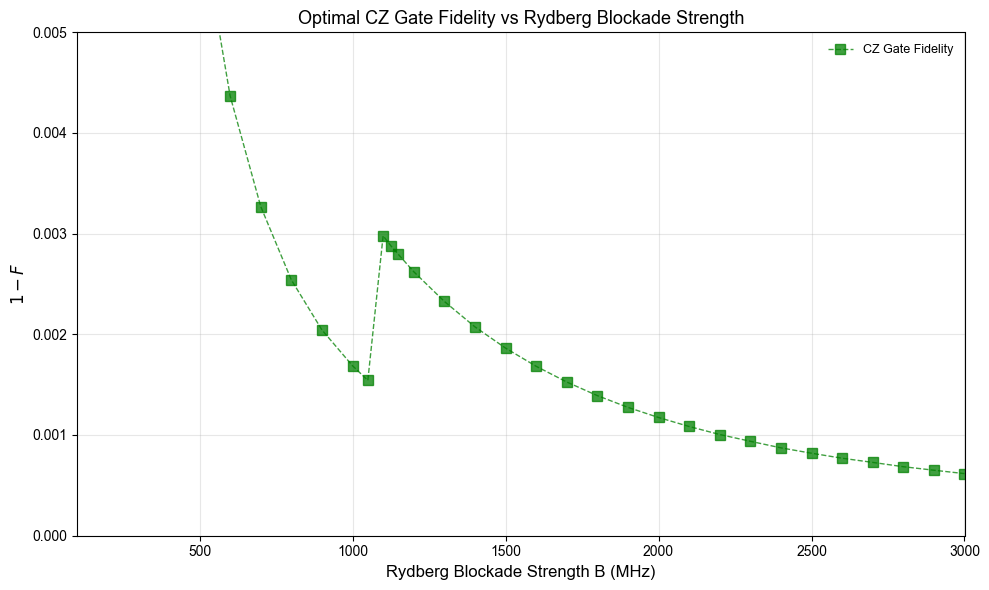


🏆 Best Fidelity Result:
  B = 3000 MHz
  Fidelity = 0.999384
  Infidelity = 6.16e-04


In [12]:
# Apply plotting configuration
plt.rcParams.update(plt_config)

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot fidelity vs B using plotting_helpers function
plot_fidelity_vs_parameter(
    ax=ax,
    param_list=df['Rydberg_B_MHz'].values,
    fidelity_list=[df['fidelity'].values],
    legend_list=['CZ Gate Fidelity'],
    title='Optimal CZ Gate Fidelity vs Rydberg Blockade Strength',
    xlabel='Rydberg Blockade Strength B (MHz)',
    ylabel='Fidelity',
    use_infidelity=True,
    log_scale=False,
    ylim=[0, 0.005],
    grid_alpha=0.3,
    show_legend=True
)

# Mark the best fidelity point
best_idx = df['fidelity'].idxmax()
# ax.plot(df.loc[best_idx, 'Rydberg_B_MHz'], 1 - df.loc[best_idx, 'fidelity'], 
#         'r*', markersize=15, label=f"Best: F={df.loc[best_idx, 'fidelity']:.6f}")
# ax.legend()

plt.tight_layout()
plt.show()

# Print best result
print(f"\n🏆 Best Fidelity Result:")
print(f"  B = {df.loc[best_idx, 'Rydberg_B_MHz']:.0f} MHz")
print(f"  Fidelity = {df.loc[best_idx, 'fidelity']:.6f}")
print(f"  Infidelity = {1 - df.loc[best_idx, 'fidelity']:.2e}")

### 3. Plot Optimized Parameters vs B

In [13]:
# Parameter bounds
bounds = {
        'T_gate': (0.0, 1.2),
        'tau_ratio': (0.175, 0.175), # Fixed tau_ratio for ARP ( why? )
        'amp_Omega_r': (15*2*np.pi, 50*2*np.pi),
        'amp_Delta_r': (15*2*np.pi, 50*2*np.pi)
    }

d:\Notion_Projects\Notion_Open_Quantum_System\qubits_simulation_codes\Neutral_Atom_Qubit_Simulations\myPkg\plotting_helpers.py:953: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(ylim)


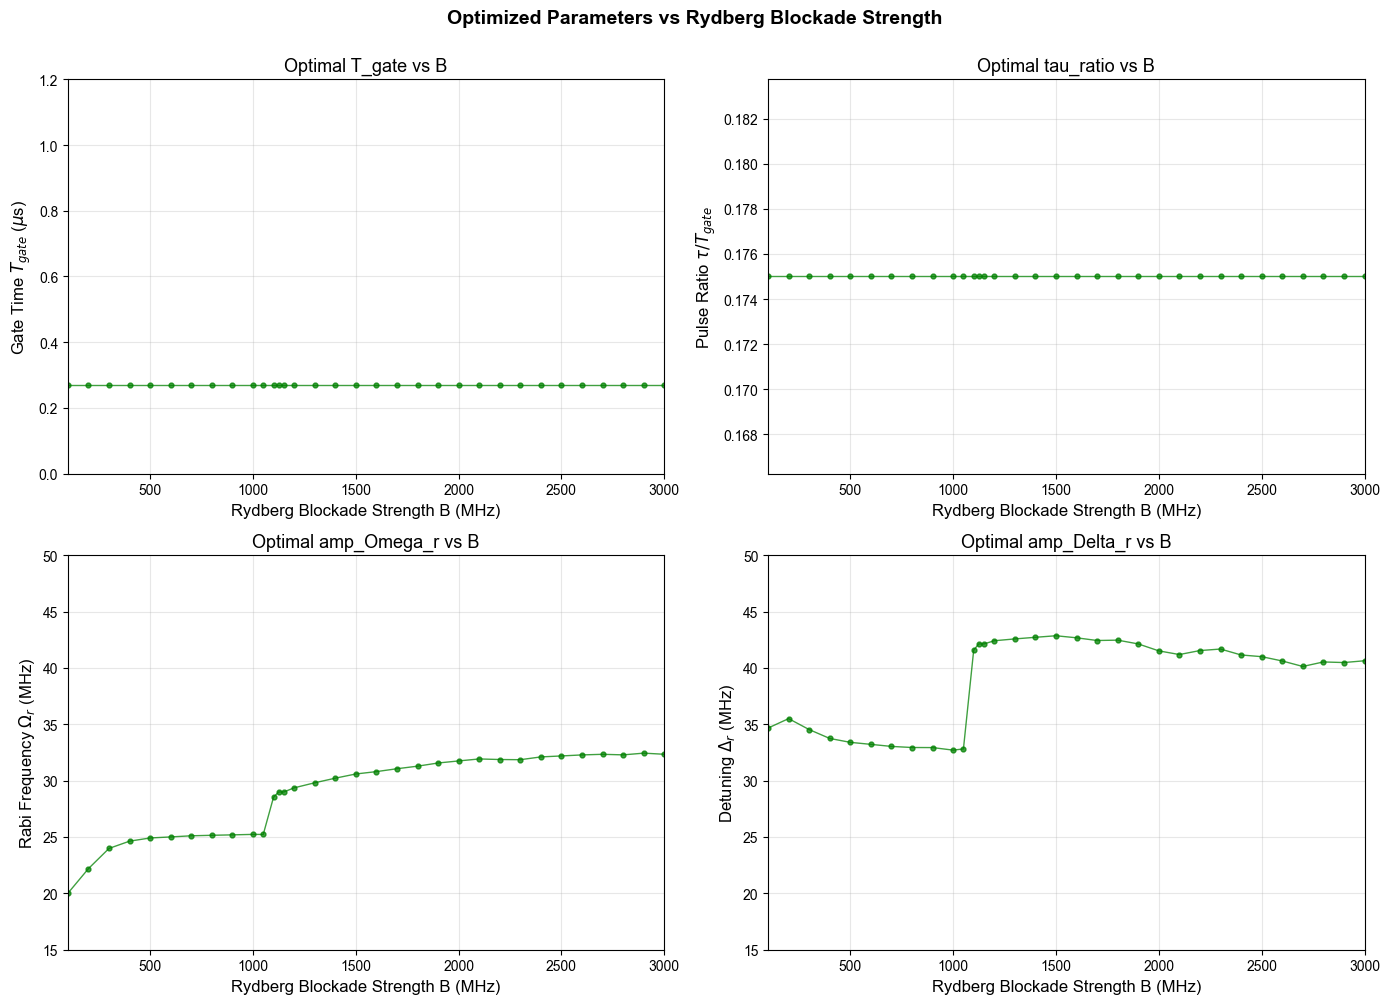

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Parameter information: (column_name, ylabel, need_conversion_to_MHz)
param_info = [
    ('T_gate', r'Gate Time $T_{gate}$ ($\mu$s)', False, axes[0, 0]),
    ('tau_ratio', r'Pulse Ratio $\tau / T_{gate}$', False, axes[0, 1]),
    ('amp_Omega_r', r'Rabi Frequency $\Omega_r$ (MHz)', True, axes[1, 0]),
    ('amp_Delta_r', r'Detuning $\Delta_r$ (MHz)', True, axes[1, 1])
]

plotstyle = {'color': 'green', 'marker': 'o', 'markersize': 3.5, 'linestyle': '-', 'linewidth': 1.0, 'alpha': 0.75,}
for param_name, ylabel, convert_to_MHz, ax in param_info:
    # Convert to appropriate units
    if convert_to_MHz:
        # Convert from rad/μs to MHz
        param_values = df[param_name].values / (2 * np.pi)
        best_val = df.loc[best_idx, param_name] / (2 * np.pi)
    else:
        param_values = df[param_name].values
        best_val = df.loc[best_idx, param_name]
    
    # Use plot_parameter_vs_parameter function
    plot_parameter_vs_parameter(
        ax=ax,
        x_param_list=df['Rydberg_B_MHz'].values,
        y_param_list=[param_values],
        legend_list=[param_name],
        title=f'Optimal {param_name} vs B',
        xlabel='Rydberg Blockade Strength B (MHz)',
        ylabel=ylabel,
        show_legend=False,
        grid_alpha=0.3,
        ylim = bounds[param_name] if not convert_to_MHz else (bounds[param_name][0]/(2*np.pi), bounds[param_name][1]/(2*np.pi)),
        plotting_style_list=[plotstyle]
    )
    
    # Mark best fidelity point
    # ax.plot(df.loc[best_idx, 'Rydberg_B_MHz'], best_val, 
    #         'r*', markersize=15, label='Best Fidelity', zorder=5)

plt.suptitle('Optimized Parameters vs Rydberg Blockade Strength', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### Observations: Parameter and Infidelity Behavior vs Rydberg Blockade Strength

**Infidelity trend:**
- For B < 1100 MHz: 

  Infidelity decreases as B increases.
- At B ≈ 1100-1150 MHz: 
  
  A sharp **discontinuous jump** in infidelity occurs, which indicates a transition.
- For B > 1150 MHz: 

  Infidelity also decreases as B increases, and shows a trend to saturation.

**Optimized pulse amplitudes ($\Omega_r$ and $\Delta_r$) trend:**
- For B < 1100 MHz: Both $\Omega_r$ and $\Delta_r$ show smooth, gradual variation, , and shows a trend to saturation until at B = 1100 MHz it mets a sudden change.
- At B ≈ 1100-1150 MHz: Both parameters exhibit an **abrupt jump** 
- For B > 1150 MHz: The parameters settle to different values and continue varying smoothly, and shows a trend to saturation.

The transitions in optimized pulse amplitudes **coincide** with the infidelity jump at the same B range.

---
### Optimized Parameters Study Case 2 : $T = 0.54$ μs $\&$ $\tau/T = 0.175$

In this analysis, we investigate how the optimized pulse amplitudes $\Omega_r$ and $\Delta_r$ vary with the Rydberg blockade strength $B$ under fixed temporal parameters:

- Gate time: $T = 0.54$ μs (fixed)
- Pulse shape parameter: $\tau/T = 0.175$ (fixed)

The only difference with case 1 is the fixed value of Gate time $T$

In [29]:
# Set multiple data directories
data_dirs = [
  'save_data/20260113_151753_CZ_gate_ARP_RydbergB_T0.54us',
  'save_data/20260113_151424_CZ_gate_ARP_RydbergB_T0.54us',
  'save_data/20260112_221352_CZ_gate_ARP_RydbergB_T0.54us_random_initials',
  'save_data/20260112_222857_CZ_gate_ARP_RydbergB_T0.54us_random_initials',
  'save_data/20260112_231909_CZ_gate_ARP_RydbergB_T0.54us',
  'save_data/20260112_094421_CZ_gate_ARP_RydbergB_T0.54us',
]

# Load and concatenate summaries
df = load_multiple_optimization_summaries(data_dirs, add_source_column=False, 
                                          drop_duplicates_by='Rydberg_B_MHz', keep_duplicate='first', sort_by='Rydberg_B_MHz', ascending=True, verbose=False)

# save concatenated summary for future use
# df = save_optimization_summary(df, 'save_data/CZ_gate_ARP_RydbergB_T0.54us_combined_summary', filename='summary054us_branch01.csv', verbose=False)

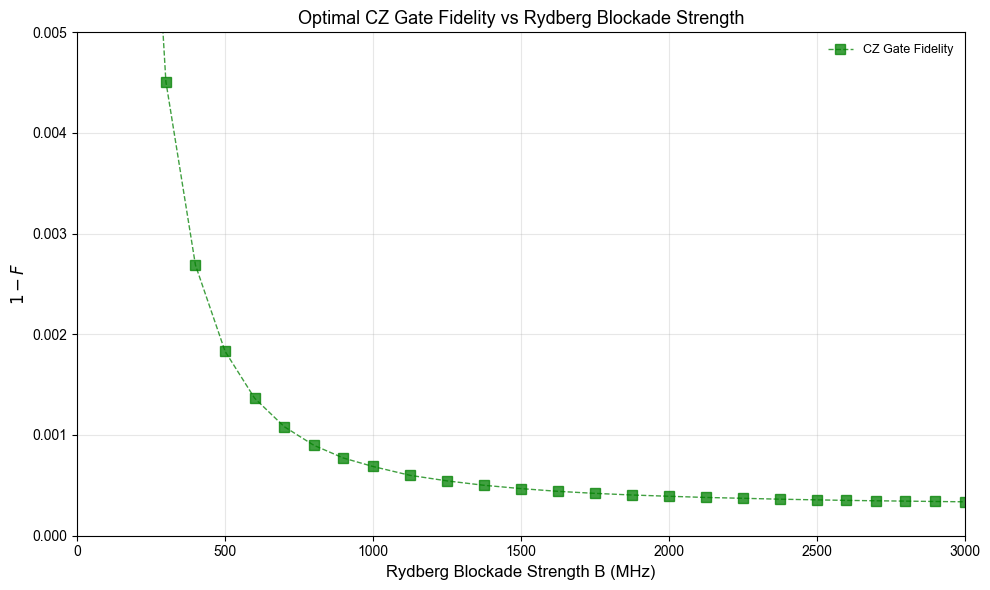


🏆 Best Fidelity Result:
  B = 3000 MHz
  Fidelity = 0.999664
  Infidelity = 3.36e-04


In [30]:
# Apply plotting configuration
plt.rcParams.update(plt_config)

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot fidelity vs B using plotting_helpers function
plot_fidelity_vs_parameter(
    ax=ax,
    param_list=df['Rydberg_B_MHz'].values,
    fidelity_list=[df['fidelity'].values],
    legend_list=['CZ Gate Fidelity'],
    title='Optimal CZ Gate Fidelity vs Rydberg Blockade Strength',
    xlabel='Rydberg Blockade Strength B (MHz)',
    ylabel='Fidelity',
    use_infidelity=True,
    log_scale=False,
    xlim=[0,3000],
    ylim=[0, 0.005],
    grid_alpha=0.3,
    show_legend=True
)

# Mark the best fidelity point
best_idx = df['fidelity'].idxmax()
# ax.plot(df.loc[best_idx, 'Rydberg_B_MHz'], 1 - df.loc[best_idx, 'fidelity'], 
#         'r*', markersize=15, label=f"Best: F={df.loc[best_idx, 'fidelity']:.6f}")
# ax.legend()

plt.tight_layout()
plt.show()

# Print best result
print(f"\n🏆 Best Fidelity Result:")
print(f"  B = {df.loc[best_idx, 'Rydberg_B_MHz']:.0f} MHz")
print(f"  Fidelity = {df.loc[best_idx, 'fidelity']:.6f}")
print(f"  Infidelity = {1 - df.loc[best_idx, 'fidelity']:.2e}")

In [31]:
bounds = {
  'T_gate': (0.0, 1.2),
  'tau_ratio': (0.175, 0.175),
  'amp_Omega_r': (10*2*np.pi, 20*2*np.pi),
  'amp_Delta_r': (15*2*np.pi, 30*2*np.pi)
}

d:\Notion_Projects\Notion_Open_Quantum_System\qubits_simulation_codes\Neutral_Atom_Qubit_Simulations\myPkg\plotting_helpers.py:953: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(ylim)


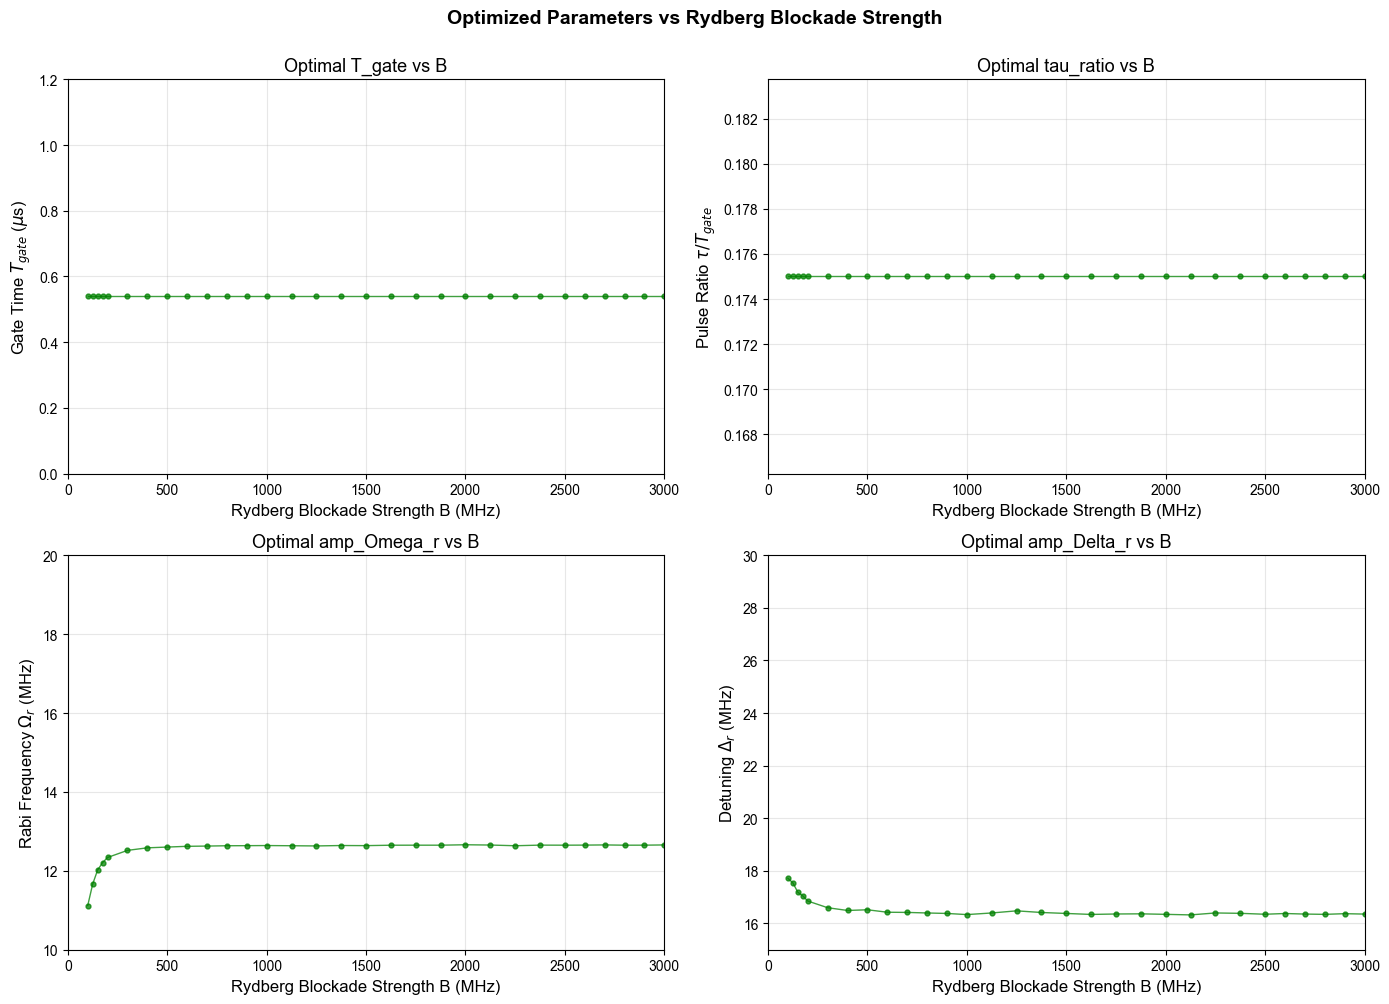

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Parameter information: (column_name, ylabel, need_conversion_to_MHz)
param_info = [
    ('T_gate', r'Gate Time $T_{gate}$ ($\mu$s)', False, axes[0, 0]),
    ('tau_ratio', r'Pulse Ratio $\tau / T_{gate}$', False, axes[0, 1]),
    ('amp_Omega_r', r'Rabi Frequency $\Omega_r$ (MHz)', True, axes[1, 0]),
    ('amp_Delta_r', r'Detuning $\Delta_r$ (MHz)', True, axes[1, 1])
]

plotstyle = {'color': 'green', 'marker': 'o', 'markersize': 3.5, 'linestyle': '-', 'linewidth': 1.0, 'alpha': 0.75,}
for param_name, ylabel, convert_to_MHz, ax in param_info:
    # Convert to appropriate units
    if convert_to_MHz:
        # Convert from rad/μs to MHz
        param_values = df[param_name].values / (2 * np.pi)
        best_val = df.loc[best_idx, param_name] / (2 * np.pi)
    else:
        param_values = df[param_name].values
        best_val = df.loc[best_idx, param_name]
    
    # Use plot_parameter_vs_parameter function
    plot_parameter_vs_parameter(
        ax=ax,
        x_param_list=df['Rydberg_B_MHz'].values,
        y_param_list=[param_values],
        legend_list=[param_name],
        title=f'Optimal {param_name} vs B',
        xlabel='Rydberg Blockade Strength B (MHz)',
        ylabel=ylabel,
        show_legend=False,
        grid_alpha=0.3,
        xlim=[0,3000],
        ylim = bounds[param_name] if not convert_to_MHz else (bounds[param_name][0]/(2*np.pi), bounds[param_name][1]/(2*np.pi)),
        plotting_style_list=[plotstyle]
    )
    
    # Mark best fidelity point
    # ax.plot(df.loc[best_idx, 'Rydberg_B_MHz'], best_val, 
    #         'r*', markersize=15, label='Best Fidelity', zorder=5)

plt.suptitle('Optimized Parameters vs Rydberg Blockade Strength', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

---
### Optimized Parameters Study Case 3 : $T = 1.08$ μs $\&$ $\tau/T = 0.175$

In this analysis, we investigate how the optimized pulse amplitudes $\Omega_r$ and $\Delta_r$ vary with the Rydberg blockade strength $B$ under fixed temporal parameters:

- Gate time: $T = 1.08$ μs (fixed)
- Pulse shape parameter: $\tau/T = 0.175$ (fixed)

The only difference with case 1 is the fixed value of Gate time $T$

In [79]:
# Set multiple data directories
data_dirs = [
    # branch 01 ----------------------------------------------------
    'save_data/20260113_194258_CZ_gate_ARP_RydbergB_T1.08us',
    'save_data/20260113_111514_CZ_gate_ARP_RydbergB_T1.08us',
    'save_data/20260113_104039_CZ_gate_ARP_RydbergB_T1.08us_random_initials',
    'save_data/20260113_114323_CZ_gate_ARP_RydbergB_T1.08us',
    'save_data/20260113_115958_CZ_gate_ARP_RydbergB_T1.08us'
    'save_data/20260113_104805_CZ_gate_ARP_RydbergB_T1.08us_random_initials',
    # branch 02 ----------------------------------------------------
    # 'save_data/20260113_191014_CZ_gate_ARP_RydbergB_T1.08us',
    # 'save_data/20260113_145058_CZ_gate_ARP_RydbergB_T1.08us',
    # 'save_data/20260113_143321_CZ_gate_ARP_RydbergB_T1.08us',
    # 'save_data/20260113_125438_CZ_gate_ARP_RydbergB_T1.08us',
    # 'save_data/20260113_124129_CZ_gate_ARP_RydbergB_T1.08us',
    # 'save_data/20260112_204523_CZ_gate_ARP_RydbergB_T1.08us_random_initials',
    # 'save_data/20260112_214345_CZ_gate_ARP_RydbergB_T1.08us',
    # branch 03 ----------------------------------------------------
    # 'save_data/20260113_133122_CZ_gate_ARP_RydbergB_T1.08us',
    # 'save_data/20260112_141404_CZ_gate_ARP_RydbergB_T1.08us',
    # 'save_data/20260113_141725_CZ_gate_ARP_RydbergB_T1.08us',
]

# Load and concatenate summaries
df = load_multiple_optimization_summaries(data_dirs, add_source_column=False, 
                                          drop_duplicates_by='Rydberg_B_MHz', keep_duplicate='first', sort_by='Rydberg_B_MHz', ascending=True, verbose=True)

df = save_optimization_summary(df, 'save_data/CZ_gate_ARP_RydbergB_T1.08us_combined_summary', filename='summary108us_branch01.csv', verbose=False)

Concatenating summary files from 5 directories

✅ Loaded: 20260113_194258_CZ_gate_ARP_RydbergB_T1.08us
   Rows: 12, Columns: ['Rydberg_B_MHz', 'fidelity', 'T_gate', 'tau_ratio', 'amp_Omega_r', 'amp_Delta_r']
✅ Loaded: 20260113_111514_CZ_gate_ARP_RydbergB_T1.08us
   Rows: 7, Columns: ['Rydberg_B_MHz', 'fidelity', 'T_gate', 'tau_ratio', 'amp_Omega_r', 'amp_Delta_r']
✅ Loaded: 20260113_104039_CZ_gate_ARP_RydbergB_T1.08us_random_initials
   Rows: 5, Columns: ['Rydberg_B_MHz', 'fidelity', 'T_gate', 'tau_ratio', 'amp_Omega_r', 'amp_Delta_r']
✅ Loaded: 20260113_114323_CZ_gate_ARP_RydbergB_T1.08us
   Rows: 12, Columns: ['Rydberg_B_MHz', 'fidelity', 'T_gate', 'tau_ratio', 'amp_Omega_r', 'amp_Delta_r']
⚠️  Not found: save_data\20260113_115958_CZ_gate_ARP_RydbergB_T1.08ussave_data\20260113_104805_CZ_gate_ARP_RydbergB_T1.08us_random_initials\summary.csv

----------------------------------------------------------------------
Summary:
  Successfully loaded: 4/5
  Failed: 1/5
------------------------

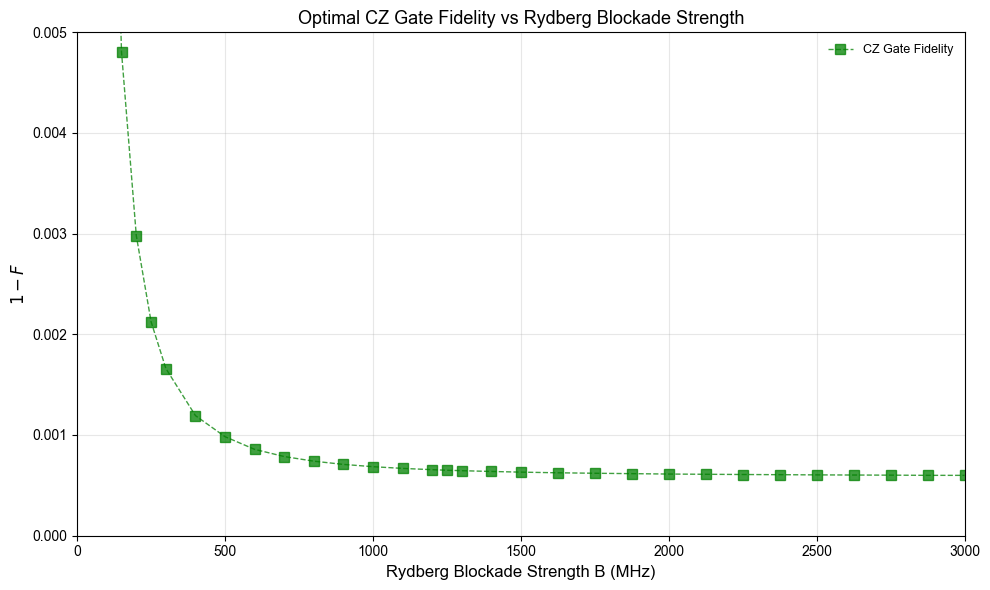


🏆 Best Fidelity Result:
  B = 3000 MHz
  Fidelity = 0.999401
  Infidelity = 5.99e-04


In [80]:
# Apply plotting configuration
plt.rcParams.update(plt_config)

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot fidelity vs B using plotting_helpers function
plot_fidelity_vs_parameter(
    ax=ax,
    param_list=df['Rydberg_B_MHz'].values,
    fidelity_list=[df['fidelity'].values],
    legend_list=['CZ Gate Fidelity'],
    title='Optimal CZ Gate Fidelity vs Rydberg Blockade Strength',
    xlabel='Rydberg Blockade Strength B (MHz)',
    ylabel='Fidelity',
    use_infidelity=True,
    log_scale=False,
    xlim=[0,3000],
    ylim=[0, 0.005],
    grid_alpha=0.3,
    show_legend=True
)

# Mark the best fidelity point
best_idx = df['fidelity'].idxmax()
# ax.plot(df.loc[best_idx, 'Rydberg_B_MHz'], 1 - df.loc[best_idx, 'fidelity'], 
#         'r*', markersize=15, label=f"Best: F={df.loc[best_idx, 'fidelity']:.6f}")
# ax.legend()

plt.tight_layout()
plt.show()

# Print best result
print(f"\n🏆 Best Fidelity Result:")
print(f"  B = {df.loc[best_idx, 'Rydberg_B_MHz']:.0f} MHz")
print(f"  Fidelity = {df.loc[best_idx, 'fidelity']:.6f}")
print(f"  Infidelity = {1 - df.loc[best_idx, 'fidelity']:.2e}")

In [81]:
bounds = {
  'T_gate': (0.0, 1.2),
  'tau_ratio': (0.175, 0.175),
  'amp_Omega_r': (3.0*2*np.pi, 12*2*np.pi),
  'amp_Delta_r': (3.0*2*np.pi, 12*2*np.pi)
}

d:\Notion_Projects\Notion_Open_Quantum_System\qubits_simulation_codes\Neutral_Atom_Qubit_Simulations\myPkg\plotting_helpers.py:953: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(ylim)


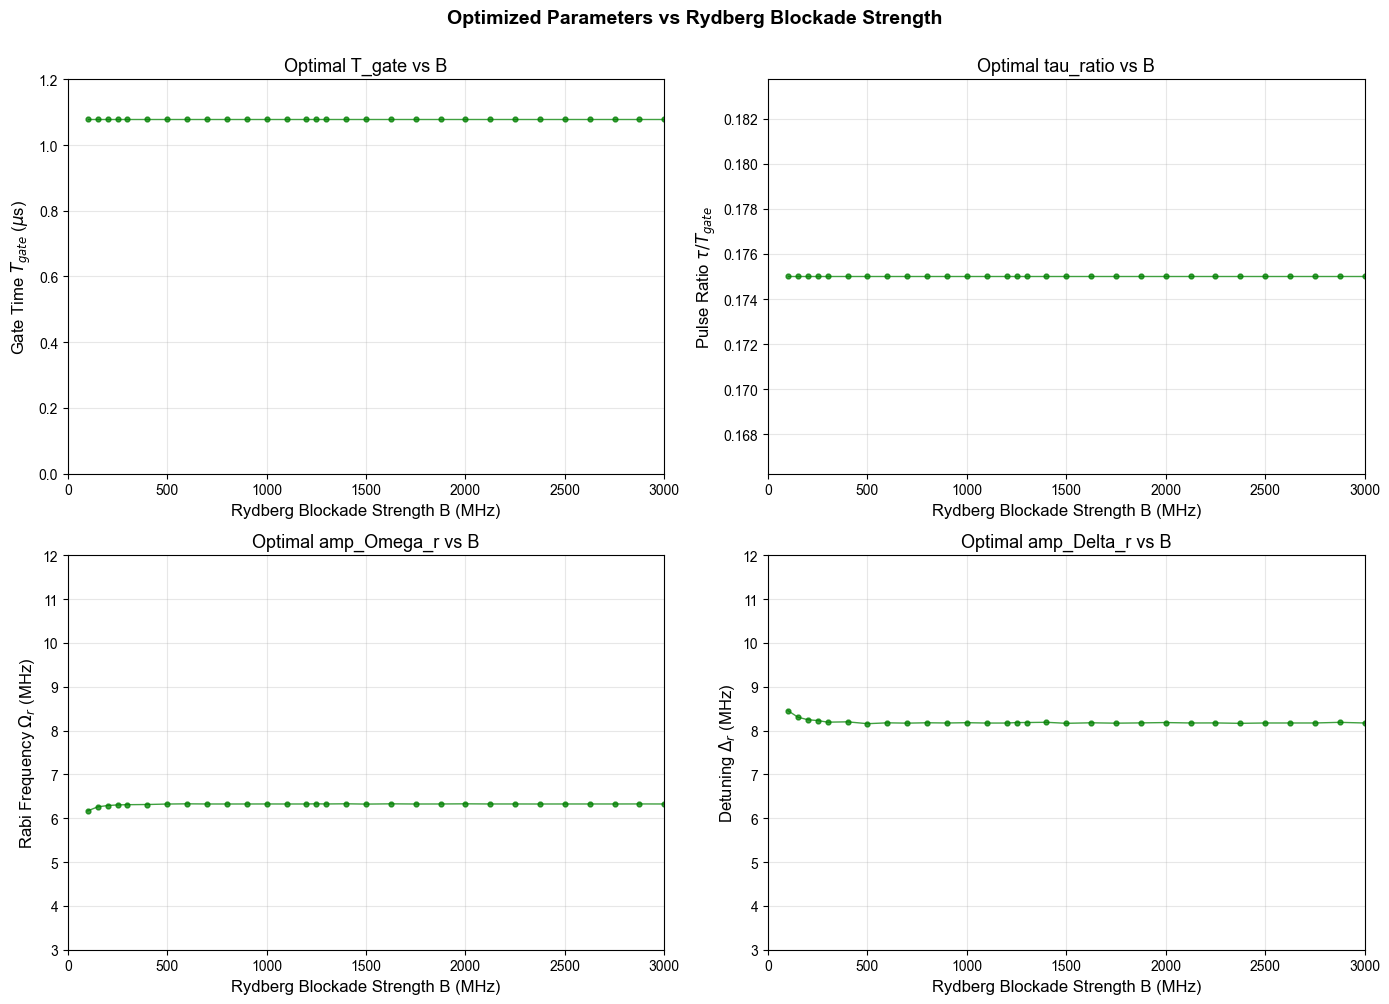

In [82]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Parameter information: (column_name, ylabel, need_conversion_to_MHz)
param_info = [
    ('T_gate', r'Gate Time $T_{gate}$ ($\mu$s)', False, axes[0, 0]),
    ('tau_ratio', r'Pulse Ratio $\tau / T_{gate}$', False, axes[0, 1]),
    ('amp_Omega_r', r'Rabi Frequency $\Omega_r$ (MHz)', True, axes[1, 0]),
    ('amp_Delta_r', r'Detuning $\Delta_r$ (MHz)', True, axes[1, 1])
]

plotstyle = {'color': 'green', 'marker': 'o', 'markersize': 3.5, 'linestyle': '-', 'linewidth': 1.0, 'alpha': 0.75,}
for param_name, ylabel, convert_to_MHz, ax in param_info:
    # Convert to appropriate units
    if convert_to_MHz:
        # Convert from rad/μs to MHz
        param_values = df[param_name].values / (2 * np.pi)
        best_val = df.loc[best_idx, param_name] / (2 * np.pi)
    else:
        param_values = df[param_name].values
        best_val = df.loc[best_idx, param_name]
    
    # Use plot_parameter_vs_parameter function
    plot_parameter_vs_parameter(
        ax=ax,
        x_param_list=df['Rydberg_B_MHz'].values,
        y_param_list=[param_values],
        legend_list=[param_name],
        title=f'Optimal {param_name} vs B',
        xlabel='Rydberg Blockade Strength B (MHz)',
        ylabel=ylabel,
        show_legend=False,
        grid_alpha=0.3,
        xlim=[0,3000],
        ylim = bounds[param_name] if not convert_to_MHz else (bounds[param_name][0]/(2*np.pi), bounds[param_name][1]/(2*np.pi)),
        plotting_style_list=[plotstyle]
    )
    
    # Mark best fidelity point
    # ax.plot(df.loc[best_idx, 'Rydberg_B_MHz'], best_val, 
    #         'r*', markersize=15, label='Best Fidelity', zorder=5)

plt.suptitle('Optimized Parameters vs Rydberg Blockade Strength', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()